# 1D harmonic oscillator

We study the 1D harmonic oscillator:

$$
V(x) = \frac{1}{2} m \omega^2 x^2
$$

The time-independent Schrödinger equation is:

$$
-\frac{\hbar^2}{2m} \frac{d^2 \psi}{dx^2} + \frac{1}{2} m \omega^2 x^2 \psi = E \psi
$$

## Dimensionless Form

Define:

$$
\xi = \sqrt{\frac{m\omega}{\hbar}}\,x
$$

Then the equation becomes:

$$
\frac{d^2 \psi}{d\xi^2} + (\lambda - \xi^2)\psi = 0
$$

where

$$
\lambda = \frac{2E}{\hbar\omega}
$$

## Solution Structure

We try:

$$
\psi(\xi) = u(\xi)e^{-\xi^2/2}
$$

This leads to:

$$
u'' - 2\xi u' + (\lambda - 1)u = 0
$$

This is the Hermite equation when:

$$
\lambda = 2n + 1
$$

Thus,

$$
E_n = \left(n + \frac{1}{2}\right)\hbar\omega
$$

and the solution is:

$$
\psi_n(x) = N_n H_n(\sqrt{\alpha}x)e^{-\alpha x^2/2}
$$

where

$$
\alpha = \frac{m\omega}{\hbar}
$$

## Hermite Polynomials

The Hermite polynomials satisfy:

$$H_n'' - 2x H_n' + 2n H_n = 0$$

First few:

$$H_0 = 1,\quad H_1 = 2x,\quad H_2 = 4x^2 - 2$$

They determine the shape of the wavefunctions.

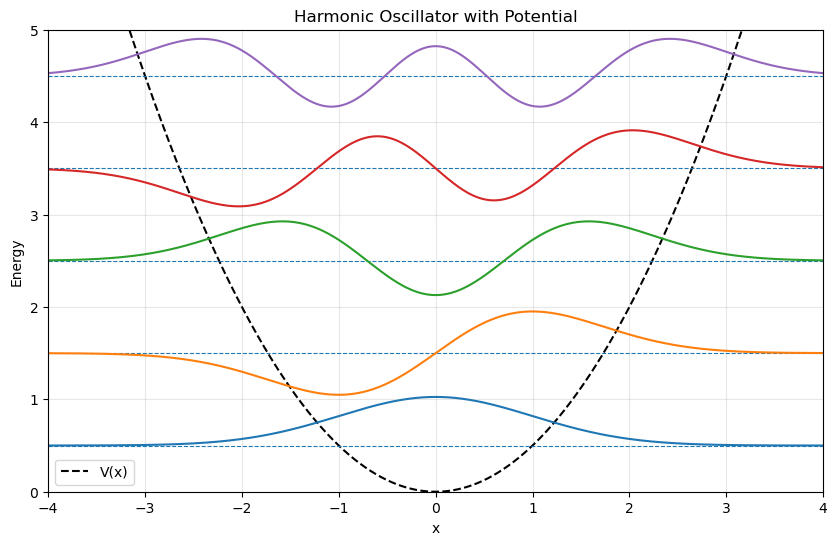

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import math

# =========================
# Hermite polynomial
# =========================
def hermite(n, x):
    if n == 0:
        return np.ones_like(x)
    elif n == 1:
        return 2*x

    H0 = np.ones_like(x)
    H1 = 2*x

    for k in range(2, n+1):
        H2 = 2*x*H1 - 2*(k-1)*H0
        H0, H1 = H1, H2

    return H1


# =========================
# wavefunction
# =========================
def psi(n, x, alpha=1.0):
    xi = np.sqrt(alpha) * x
    Hn = hermite(n, xi)

    norm = (alpha/np.pi)**0.25 / np.sqrt(2**n * math.factorial(n))
    return norm * Hn * np.exp(-0.5 * alpha * x**2)


# =========================
# setup
# =========================
x = np.linspace(-4, 4, 10000)

plt.figure(figsize=(10,6))

# ===== 画势能（虚线）=====
V = 0.5 * x**2
plt.plot(x, V, 'k--', linewidth=1.5, label="V(x)")

# ===== 画波函数 =====
scale = 0.7  # 控制波函数高度

for n in range(10):
    y = psi(n, x)
    E = n + 0.5

    # 能级线
    plt.hlines(E, -4, 4, linestyles='dashed', linewidth=0.8)

    # 波函数（平移到能级）
    plt.plot(x, E + scale*y)

# ===== 图像设置 =====
plt.title("Harmonic Oscillator with Potential")
plt.xlabel("x")
plt.ylabel("Energy")

plt.xlim(-4, 4)
plt.ylim(0, 5)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

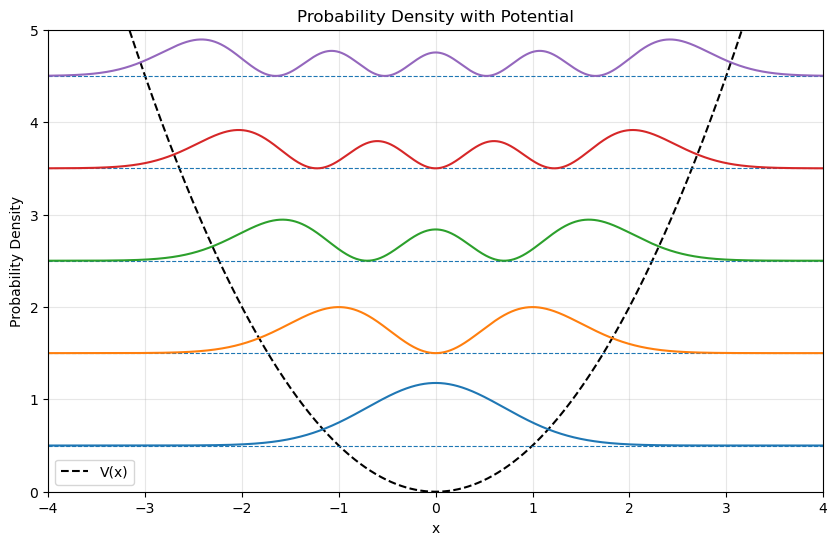

In [22]:
plt.figure(figsize=(10,6))

# 势能
plt.plot(x, V, 'k--', linewidth=1.5, label="V(x)")

scale = 1.2

for n in range(10):
    y = psi(n, x)**2
    E = n + 0.5

    plt.hlines(E, -4, 4, linestyles='dashed', linewidth=0.8)
    plt.plot(x, E + scale*y)

plt.title("Probability Density with Potential")
plt.xlabel("x")
plt.ylabel("Probability Density")

plt.xlim(-4, 4)
plt.ylim(0, 5)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

## Observations

- The number of nodes equals \( n \)
- The ground state has no nodes
- Higher energy states spread out
- Probability density peaks near classical turning points

## Animation of 1D Harmonic Oscillator States

This animation shows the energy eigenstates of the 1D quantum harmonic oscillator.

We use the dimensionless potential

$$
V(x)=\frac{1}{2}x^2
$$

and the energy levels

$$
E_n = n+\frac{1}{2}, \qquad n=0,1,2,\dots
$$

The wavefunction is

$$
\psi_n(x)=
\frac{1}{\pi^{1/4}\sqrt{2^n n!}}
H_n(x)e^{-x^2/2}
$$

and the probability density is

$$
|\psi_n(x)|^2
$$

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -------------------------
# Hermite polynomial
# -------------------------
def hermite(n, x):
    if n == 0:
        return np.ones_like(x)
    elif n == 1:
        return 2 * x

    H0 = np.ones_like(x)
    H1 = 2 * x
    for k in range(2, n + 1):
        H2 = 2 * x * H1 - 2 * (k - 1) * H0
        H0, H1 = H1, H2
    return H1

# -------------------------
# Normalized wavefunction
# dimensionless form: alpha = 1
# -------------------------
def psi(n, x):
    Hn = hermite(n, x)
    norm = 1.0 / (np.pi**0.25 * np.sqrt((2**n) * math.factorial(n)))
    return norm * Hn * np.exp(-x**2 / 2)

# -------------------------
# Grid and static data
# -------------------------
x = np.linspace(-5, 5, 1200)
V = 0.5 * x**2

n_max = 10
wave_scale = 0.8
prob_scale = 1.5

# -------------------------
# Figure
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax1, ax2 = axes

# Left: wavefunction
ax1.plot(x, V, 'k--', linewidth=1.5, label=r'$V(x)=x^2 / 2$')
ax1.set_xlim(-5, 5)
ax1.set_ylim(0, n_max + 2)
ax1.set_xlabel('x')
ax1.set_ylabel('Energy / shifted curve')
ax1.set_title(r'Wavefunction $\psi_n(x)$')
ax1.grid(alpha=0.3)

# Right: probability density
ax2.plot(x, V, 'k--', linewidth=1.5, label=r'$V(x)=x^2/2$')
ax2.set_xlim(-5, 5)
ax2.set_ylim(0, n_max + 2.5)
ax2.set_xlabel('x')
ax2.set_ylabel('Energy / shifted curve')
ax2.set_title(r'Probability density $|\psi_n(x)|^2$')
ax2.grid(alpha=0.3)

# Dynamic artists
energy_line1 = ax1.hlines(0, -5, 5, linestyles='dashed', linewidth=1.0)
energy_line2 = ax2.hlines(0, -5, 5, linestyles='dashed', linewidth=1.0)

wave_line, = ax1.plot([], [], linewidth=2)
prob_line, = ax2.plot([], [], linewidth=2)

turn_left1 = ax1.axvline(0, linestyle='dashed', linewidth=1)
turn_right1 = ax1.axvline(0, linestyle='dashed', linewidth=1)
turn_left2 = ax2.axvline(0, linestyle='dashed', linewidth=1)
turn_right2 = ax2.axvline(0, linestyle='dashed', linewidth=1)

text1 = ax1.text(0.02, 0.95, '', transform=ax1.transAxes, va='top', fontsize=12)
text2 = ax2.text(0.02, 0.95, '', transform=ax2.transAxes, va='top', fontsize=12)

ax1.legend()
ax2.legend()

# -------------------------
# Update function
# -------------------------
def update(n):
    global energy_line1, energy_line2

    E = n + 0.5
    y = psi(n, x)
    p = y**2
    x_turn = np.sqrt(2 * E)  # classical turning point from V(x)=E

    # remove old energy lines and redraw
    energy_line1.remove()
    energy_line2.remove()
    energy_line1 = ax1.hlines(E, -5, 5, linestyles='dashed', linewidth=1.0)
    energy_line2 = ax2.hlines(E, -5, 5, linestyles='dashed', linewidth=1.0)

    # update wave / density
    wave_line.set_data(x, E + wave_scale * y)
    prob_line.set_data(x, E + prob_scale * p)

    # update turning points
    turn_left1.set_xdata([-x_turn, -x_turn])
    turn_right1.set_xdata([x_turn, x_turn])
    turn_left2.set_xdata([-x_turn, -x_turn])
    turn_right2.set_xdata([x_turn, x_turn])

    # update text
    text1.set_text(rf'$n={n}$' + '\n' + rf'$E_n={E:.1f}$')
    text2.set_text(rf'$n={n}$' + '\n' + rf'$E_n={E:.1f}$')

    return (
        wave_line, prob_line,
        turn_left1, turn_right1, turn_left2, turn_right2,
        text1, text2,
        energy_line1, energy_line2
    )

# -------------------------
# Animation
# -------------------------
anim = FuncAnimation(
    fig,
    update,
    frames=range(0, n_max + 1),
    interval=900,   # milliseconds per frame
    blit=False,
    repeat=True
)

plt.close(fig)  # avoid duplicate static figure
HTML(anim.to_jshtml())

In [19]:
anim.save("harmonic_oscillator.gif", writer="pillow", fps=1.2)

### Physical meaning

As \(n\) increases:

- the number of nodes increases,
- the wavefunction spreads over a wider region,
- the probability density becomes more concentrated near the classical turning points,
- the behavior gradually approaches the classical picture.